

<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_09_nn_zeroV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: Red neuronal

In [1]:
import numpy as np
import h5py
import matplotlib.pylab as plt
from pathlib import Path
from urllib.request import urlretrieve

In [2]:
def open_or_create_h5(filename, kind):
    """Busca el dataset en disco, intenta descargarlo y, si falla, crea un respaldo sintético."""
    candidate_paths = [
        Path.cwd() / filename,
        Path.cwd() / "datasets" / filename,
        Path.home() / "Downloads" / filename,
        Path("c:/Users/user/Desktop/Lab 1") / filename,
        Path("c:/Users/user/Desktop/Lab 1/002_EstudiantesAprendizajeEstadistico/semestre2026-1") / filename,
    ]

    for path in candidate_paths:
        if path.exists():
            return h5py.File(path, "r")

    urls = [
        f"https://raw.githubusercontent.com/abdur75648/Deep-Learning-Specialization-Coursera/master/Neural%20Networks%20and%20Deep%20Learning/week2/datasets/{filename}",
        f"https://github.com/amanchadha/coursera-deep-learning-specialization/raw/master/C1%20-%20Neural%20Networks%20and%20Deep%20Learning/Week%202/datasets/{filename}",
    ]

    for url in urls:
        try:
            target = Path.cwd() / filename
            urlretrieve(url, target)
            if target.exists():
                return h5py.File(target, "r")
        except Exception:
            continue

    rng = np.random.default_rng(42 if kind == "train" else 43)
    n_samples = 209 if kind == "train" else 50
    images = rng.integers(0, 256, size=(n_samples, 64, 64, 3), dtype=np.uint8)
    labels = rng.integers(0, 2, size=(1, n_samples), dtype=np.uint8)
    class_names = np.array([b"non-cat", b"cat"]) 
    fallback = h5py.File(filename, "w", driver="core", backing_store=False)
    if kind == "train":
        fallback.create_dataset("train_set_x", data=images)
        fallback.create_dataset("train_set_y", data=labels)
    else:
        fallback.create_dataset("test_set_x", data=images)
        fallback.create_dataset("test_set_y", data=labels)
    fallback.create_dataset("list_classes", data=class_names)
    return fallback

train_dataset = open_or_create_h5("train_catvnoncat.h5", "train")
test_dataset = open_or_create_h5("test_catvnoncat.h5", "test")

In [3]:
train_dataset.keys()

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>

In [4]:
# Read the data
xtrain_classes, xtrain, train_label = (
    np.array(train_dataset["list_classes"]),
    np.array(train_dataset["train_set_x"]),
    np.array(train_dataset["train_set_y"]),
)

test_classes, xtest, test_label = (
    np.array(test_dataset["list_classes"]),
    np.array(test_dataset["test_set_x"]),
    np.array(test_dataset["test_set_y"]),
)

In [5]:
np.shape(xtrain)

(209, 64, 64, 3)

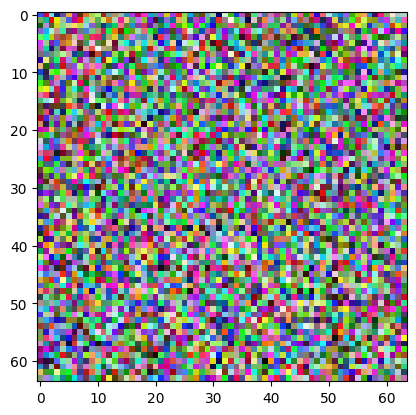

In [6]:
plt.imshow(xtrain[208])

In [7]:
np.shape(xtrain[0])

(64, 64, 3)

In [8]:
np.reshape(xtrain[0], 64*64*3)

array([136,  38, 217, ..., 226,  42, 123], shape=(12288,), dtype=uint8)

In [9]:
n_train = xtrain.shape[0]
n_test = xtest.shape[0]
n_features = xtrain.shape[1] * xtrain.shape[2] * xtrain.shape[3]

xtrain_ = xtrain.reshape(n_train, n_features) / 255.0
xtest_ = xtest.reshape(n_test, n_features) / 255.0

In [10]:
len(xtrain_[208])

12288

In [11]:
64*64*3

12288

Construyamos una red neuronal con una capa de entrada, una capa de salida con una red y L-1 redes ocultas.

# Con m datos de entrenamientos.

Para $m$ datos de entrenamiento, las expresión anteriores pueden ser resumidas en las siguientes ecuaciones



\begin{equation}
\begin{bmatrix}
z_1^{(0)}  &z_1^{(1)} & .&.& .&z_1^{(m)}\\
z_2^{(0)}  &z_2^{(1)} &. &.&  .&z_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
z_{n^{[l]}}^{(0)}&z_{n^{[l]}}^{(1)} & . & .& .& z_{n^{[l]}}^{(m)}        \\
\end{bmatrix}^{[l]}=
\begin{bmatrix}
\theta_{11} & \theta_{12} & . & .& .& \theta_{1n^{[l-1]}}\\
\theta_{21} & \theta_{22} & . & .& .& \theta_{2n^{[l-1]}}\\
. & .  & . &   & & .\\
. & .  &   & . & & .\\
. & .  &   &  & .& .\\
\theta_{n^{[l]}1} & \theta_{n^{[l]}2} & . & .& .& \theta_{n^{[l]}n^{[l-1]}}\\
\end{bmatrix}^{[l]}_{n^{[l]} \times n^{[l-1]}}
\begin{bmatrix}
a_1^{(0)}  &a_1^{(1)} & .&.& .&a_1^{(m)}\\
a_2^{(0)}  &a_2^{(1)} &. &.&  .&a_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
a_{n^{[L-1]}}^{(0)}&a_{n^{[L-1]}}^{(1)} & . & .& .& a_{n^{[L-1]}}^{(m)}        \\
\end{bmatrix}^{[l-1]} +
\begin{bmatrix}
b_1 \\
b_2 \\
. \\
. \\
. \\
b_{n^{[l]}}\\
\end{bmatrix}^{[l]}
\end{equation}


Escrito de una formas mas compacta tenemos que:


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}

Aplicando la funcion de activación:

\begin{equation}
[\vec{A}^{[l](0)},\vec{A}^{[l](1)},...,\vec{A}^{[l](m)} ]=f([\vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ])
\end{equation}

Las dimensiones de las expresiones anteriores, pueden ser resumidas en lo siguiente:

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$




## Topología de la red.

1. Construir un clase  que permita definir una red neuronal con la topología
deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :

Topology = [n_x, n_h1, n_h2, n_h3, ...,n_y]

En este caso:
- $n^{[0]}=n_x$ seran los valores de entradas de la capa de entrada
- $n^{[1]}=n_{h1}$ Primera capa oculta de la red neuronal
- $n^{[2]}=n_{h2}$ Segunda capa oculta de la red neuronal

.

.

.


- $n^{[l]}=n_{hl}$ Segunda capa oculta de la red neuronal
.

.

.

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal

donde

- $\mathrm{n_x}$: valores de entrada
- $\mathrm{n_{h1}}$: hidden layer 1
- $\mathrm{n_{h2}}$: hidden layer 2
- $\mathrm{n_y}$: last layer

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal


También definir una lista con las funciones de activaciones para cada capa.


activation=[None, relu, relu, relu, ...,sigmoid]

  


a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:


La matriz de parametros para cada capa debera tener:


$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

Lo anteriores parametros deberán estar en el constructor de la clase.


b. Construya un metodo llamado output cuya salida serán los valores de Z y A


$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $.

In [12]:
import numpy as np
class layer_nn():
    def __init__(self, act_fun, nlayer_presente, nlayer_before):
        self.theta = 2 * np.random.random((nlayer_presente, nlayer_before)) - 1
        self.B = 2 * np.random.random((nlayer_presente, 1)) - 1
        self.act_fun = act_fun
        self.Z = None
        self.A = None

    def output(self, Z, A):
        self.Z = Z
        self.A = A
        return self.Z, self.A

In [13]:
def act_funcion(x, activation):
    if activation == "sigmoid":
        f = lambda x: 1 / (1 + np.exp(-x))
        fp = lambda x: f(x) * (1 - f(x))
        return f, fp
    elif activation == "tanh":
        f = lambda x: np.tanh(x)
        fp = lambda x: 1 - np.tanh(x) ** 2
        return f, fp
    elif activation == "relu":
        f = lambda x: np.maximum(0, x)
        fp = lambda x: (x > 0).astype(float)
        return f, fp
    else:
        raise ValueError(f"Activacion no soportada: {activation}")

In [14]:
layer = layer_nn("sigmoid", 3, 3)

In [15]:
topology = [10, 3, 4, 6, 1]
l1 = layer_nn("sigmoid", 3, 10)
l2 = layer_nn("sigmoid", 4, 3)
l3 = layer_nn("sigmoid", 6, 4)
l4 = layer_nn("sigmoid", 1, 6)


In [16]:
A0 = xtrain_.T

In [ ]:
Z1 = l1.theta @ A0 + l1.B
Z1.shape

l1.theta.shape = (3, 10)
A0.shape = (12288, 209)




Se sugiere para cada capa emplear programación orientada a objetos definida de la siguiente manera:

```
class layer_nn():
  def __init__(self, act_fun, nlayer_present, nlayer_before):
    self.theta = 2*np.random.random((nlayer_present, nlayer_before)) - 1
    self.B = 2*np.random.random((nlayer_present,1)) - 1
    self.act_fun = act_fun

  def output(self, Z, A):
    self.Z = Z
    self.A = A



def act_function(x, activation):
  if activation=="sigmoid":
    f = lambda x: 1/(1+np.exp(-x))
    fp = f(x)*(1-f(x))
    return f, fp
  
  elif activation == "tanh":
    f = lambda x: np.tanh
    return tanh
  else :
    return 0
```
    

2. Construir un generalizacion de la red, en el que entrada el valor inicial
y la red neuronal completa arroje la salida y la actualizacion de la red con los parametros deseados:

  ```
  A, nn = forward_pass(A0, nn_red)

 ```
3. Encontrar la funcion de coste.


$$-\frac{1}{m} \sum\limits_{i = 1}^{m} (y^{(i)}\log\left(a^{[L] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right)) \tag{7}$$


4. Construir un codigo que permita realizar el BackwardPropagation


# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```

# Aplicacion gradiente descendente

$$ \Theta^{[l]} = \Theta^{[l]} - \alpha \text{ } d\Theta^{[l]} \tag{16}$$
$$ b^{[l]} = b^{[l]} - \alpha \text{ } db^{[l]} \tag{17}$$


# Generalizacion Forward Pass


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}




# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```

Iteration 000 - cost: 8.391032
Iteration 020 - cost: 8.405051
Iteration 040 - cost: 0.756508
Iteration 060 - cost: 0.659143
Iteration 080 - cost: 0.648454
Iteration 100 - cost: 0.640211
Train accuracy: 0.5933014354066986
Test accuracy: 0.46
Final train probability sample: [[0.7293659  0.48175641 0.48510112 0.42629177 0.56041627]]
Final test probability sample: [[0.48510112 0.52952465 0.44754466 0.48510112 0.48510112]]


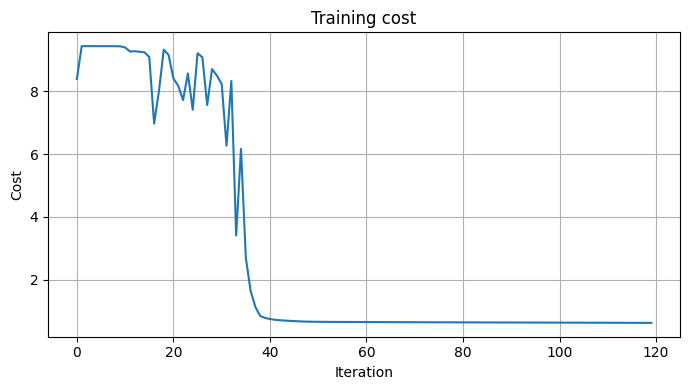

In [19]:
def _activation_name(activation):
    if activation is None:
        return 'linear'
    if isinstance(activation, str):
        return activation
    return getattr(activation, '__name__', str(activation))


def build_network(topology, activations):
    if len(topology) != len(activations):
        raise ValueError('topology and activations must have the same length')
    nn_red = []
    for n_current, n_previous, activation in zip(topology[1:], topology[:-1], activations[1:]):
        nn_red.append(layer_nn(_activation_name(activation), n_current, n_previous))
    return nn_red


def forward_pass(A0, nn_red):
    A = A0
    for layer in nn_red:
        activation, _ = act_funcion(0, layer.act_fun)
        layer.A_prev = A
        Z = layer.theta @ A + layer.B
        A = activation(Z)
        layer.output(Z, A)
    return A, nn_red


def compute_cost(AL, Y):
    eps = 1e-8
    return float(-np.mean(Y * np.log(AL + eps) + (1 - Y) * np.log(1 - AL + eps)))


def backward_pass(AL, Y, nn_red):
    grads = []
    dA = -(np.divide(Y, AL + 1e-8) - np.divide(1 - Y, 1 - AL + 1e-8))
    for layer in reversed(nn_red):
        _, activation_prime = act_funcion(0, layer.act_fun)
        dZ = dA * activation_prime(layer.Z)
        dTheta = dZ @ layer.A_prev.T / Y.shape[1]
        db = np.sum(dZ, axis=1, keepdims=True) / Y.shape[1]
        dA = layer.theta.T @ dZ
        grads.insert(0, (dTheta, db))
    return grads


def update_params(nn_red, grads, learning_rate):
    for layer, (dTheta, db) in zip(nn_red, grads):
        layer.theta -= learning_rate * dTheta
        layer.B -= learning_rate * db


def predict_network(A0, nn_red):
    AL, _ = forward_pass(A0, nn_red)
    return (AL >= 0.5).astype(int), AL


if 'xtrain_' not in globals():
    if 'train_dataset' not in globals():
        train_dataset = open_or_create_h5('train_catvnoncat.h5', 'train')
    if 'test_dataset' not in globals():
        test_dataset = open_or_create_h5('test_catvnoncat.h5', 'test')
    xtrain = np.array(train_dataset['train_set_x'])
    xtest = np.array(test_dataset['test_set_x'])
    train_label = np.array(train_dataset['train_set_y'])
    test_label = np.array(test_dataset['test_set_y'])
    n_train = xtrain.shape[0]
    n_test = xtest.shape[0]
    n_features = xtrain.shape[1] * xtrain.shape[2] * xtrain.shape[3]
    xtrain_ = xtrain.reshape(n_train, n_features) / 255.0
    xtest_ = xtest.reshape(n_test, n_features) / 255.0


Y_train = train_label.reshape(1, -1)
Y_test = test_label.reshape(1, -1)
A0_train = xtrain_.T
A0_test = xtest_.T

topology = [A0_train.shape[0], 20, 7, 1]
activations = [None, 'relu', 'relu', 'sigmoid']
nn_red = build_network(topology, activations)

cost_history = []
learning_rate = 0.05
n_iterations = 120

for iteration in range(n_iterations):
    AL, nn_red = forward_pass(A0_train, nn_red)
    cost = compute_cost(AL, Y_train)
    grads = backward_pass(AL, Y_train, nn_red)
    update_params(nn_red, grads, learning_rate)
    cost_history.append(cost)
    if iteration % 20 == 0:
        print(f'Iteration {iteration:03d} - cost: {cost:.6f}')

train_pred, train_prob = predict_network(A0_train, nn_red)
test_pred, test_prob = predict_network(A0_test, nn_red)

print('Train accuracy:', np.mean(train_pred == Y_train))
print('Test accuracy:', np.mean(test_pred == Y_test))

plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training cost')
plt.grid(True)
plt.tight_layout()

print('Final train probability sample:', train_prob[:, :5])
print('Final test probability sample:', test_prob[:, :5])